# How GenAI Understands Text

learn how modern Generative AI (GenAI) models, such as Large Language Models (LLMs), process and understand human language.

**Objectives:**
- Understand the difference between traditional rule-based NLP and modern GenAI approaches
- Learn about tokenization and embeddings
- Visualize how text is processed by GenAI models
- Explore real-world use cases
- Try hands-on demos with Hugging Face tools

#### Lesson Overview and Objectives

In this lesson, we will:
- Compare traditional rule-based NLP with modern GenAI approaches
- Explore how LLMs process text using tokenization and embeddings
- Visualize the journey of text through a GenAI model
- See practical demos and use cases

#### Traditional Rule-Based NLP Approaches

Before GenAI, NLP relied heavily on hand-crafted rules and pattern matching.

**Examples:**
- Regular expressions (regex) for extracting patterns
- Rule-based tokenization (splitting text by spaces or punctuation)
- Dictionaries for spelling correction

These methods work well for simple, well-defined tasks.


In [ ]:
# Example: Rule-based tokenization using regex
import re
text = "Hello, world! Welcome to NLP."
tokens = re.findall(r'\b\w+\b', text)
print("Tokens:", tokens)

#### Limitations of Rule-Based NLP (with Examples)

Rule-based NLP struggles with:
- Ambiguity: Words with multiple meanings (e.g., "bank" as a river bank or a financial institution)
- Language variability: Slang, typos, new words
- Context: Understanding meaning beyond simple patterns

**Example:**
- Regex can extract dates, but fails with unusual formats or typos
- Hand-crafted rules are hard to scale for complex tasks


#### Modern GenAI: Tokenization and Embeddings

Modern GenAI models use a different approach:
- **Tokenization:** Splitting text into smaller units (tokens), such as words or subwords
- **Embeddings:** Mapping tokens to high-dimensional vectors that capture meaning

This allows models to handle ambiguity, context, and language variability much better than rule-based systems.


#### Visualizing Tokenization with Hugging Face Tokenizer

Let's see how a modern tokenizer splits text into tokens. We'll use Hugging Face's `transformers` library for this demo.


In [ ]:
# Install transformers if not already installed
!pip install -q transformers

In [29]:
from transformers import AutoTokenizer

# Load a pretrained tokenizer (e.g., BERT)
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

sample_text = "Bank of America started adopting AI. Americans are excited!"
tokens = tokenizer.tokenize(sample_text)
print("Tokens:", tokens)

Tokens: ['bank', 'of', 'america', 'started', 'adopting', 'ai', '.', 'americans', 'are', 'excited', '!']


#### Visualizing Embeddings (with Illustration)

After tokenization, each token is mapped to a vector (embedding) in a high-dimensional space. These embeddings capture the meaning and context of words.

Let's extract and visualize embeddings for our sample text.


In [22]:
#!pip install --force-reinstall matplotlib

In [30]:
from transformers import AutoModel
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [31]:
# Load model
model = AutoModel.from_pretrained('bert-base-uncased')

# Tokenize and get input IDs
tokens = tokenizer(sample_text, return_tensors='pt')

with torch.no_grad():
    outputs = model(**tokens)
    embeddings = outputs.last_hidden_state.squeeze(0)

In [32]:
len(embeddings) # Number of tokens


13

In [33]:
embeddings.shape

torch.Size([13, 768])

In [34]:
tokens

{'input_ids': tensor([[  101,  2924,  1997,  2637,  2318, 16151,  9932,  1012,  4841,  2024,
          7568,   999,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

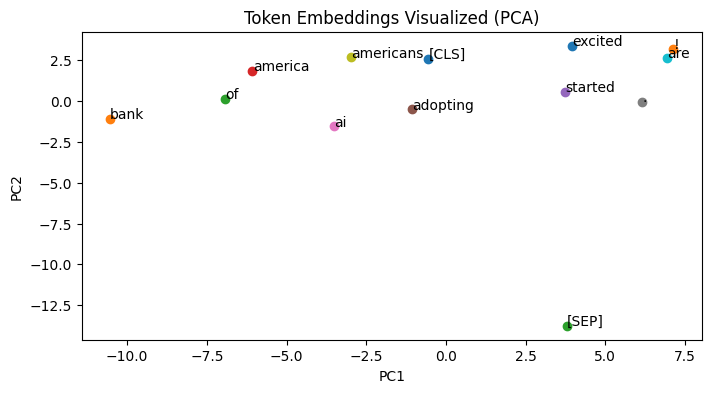

In [35]:
# Reduce dimensions for visualization
pca = PCA(n_components=2)

#converts your PyTorch tensor to a NumPy array because scikit-learn’s PCA expects NumPy input.
embeddings_2d = pca.fit_transform(embeddings.numpy())

# Plot
plt.figure(figsize=(8,4))
for i, token in enumerate(tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])):
    plt.scatter(embeddings_2d[i,0], embeddings_2d[i,1])
    plt.text(embeddings_2d[i,0]+0.01, embeddings_2d[i,1]+0.01, token)
plt.title('Token Embeddings Visualized (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

#### How LLMs Process Text Step-by-Step

Let's break down the journey of text through a GenAI model:

1. **Input:** Raw text is provided (e.g., a sentence or paragraph)
2. **Tokenization:** Text is split into tokens (subwords/words)
3. **Embedding:** Each token is mapped to a vector
4. **Model Layers:** Embeddings are processed through multiple neural network layers
5. **Output:** The model generates predictions (e.g., next word, answer, summary)


#### Use Cases of GenAI Text Understanding

Modern GenAI models are used in a wide range of applications:

- **Chatbots & Virtual Assistants:** Natural conversations with users
- **Text Summarization:** Condensing long documents
- **Machine Translation:** Translating between languages
- **Sentiment Analysis:** Understanding opinions in text
- **Code Generation:** Writing code from natural language
- **Question Answering:** Extracting answers from documents
- **Content Generation:** Writing articles, stories, emails


#### Demo: Exploring Tokenization and Embeddings in Practice

Let's try an interactive demo! Enter your own text to see how it is tokenized and embedded by a GenAI model.

In [12]:
# Interactive demo: Enter your own text
from IPython.display import display
import ipywidgets as widgets

In [13]:
def show_tokenization_and_embeddings(text):
    tokens = tokenizer.tokenize(text)
    print("Tokens:", tokens)
    
    inputs = tokenizer(text, return_tensors='pt')
    
    with torch.no_grad():
        outputs = model(**inputs)
        embeddings = outputs.last_hidden_state.squeeze(0)
        
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings.numpy())
    
    plt.figure(figsize=(8,4))
    for i, token in enumerate(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])):
        plt.scatter(embeddings_2d[i,0], embeddings_2d[i,1])
        plt.text(embeddings_2d[i,0]+0.01, embeddings_2d[i,1]+0.01, token)
    plt.title('Token Embeddings Visualized (PCA)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

text_box = widgets.Textarea(value='GenAI is transforming NLP!', description='Input Text:', layout=widgets.Layout(width='80%', height='60px'))
button = widgets.Button(description='Show Tokenization & Embeddings')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        show_tokenization_and_embeddings(text_box.value)

button.on_click(on_button_clicked)
display(text_box, button, output)

Textarea(value='GenAI is transforming NLP!', description='Input Text:', layout=Layout(height='60px', width='80…

Button(description='Show Tokenization & Embeddings', style=ButtonStyle())

Output()